# $\kappa$-bounded $A$ + residual reg $\lambda=10^{-2}$ (rk4, 5 seeds)

Single-config test of the highest-priority pathway from the $\kappa$ analysis. The plant, partial
measurement $y=q$, encoder/decoder, **fixed-step rk4** rollout, trainer, and diagnostics are reused
**verbatim** from `duffing_partial_obs_latent_ftnode_res_sweep_5lambda_10seed.ipynb`; the **only**
change is the construction of $A(z)$.

**What changed.** Previously $A(z)=-(LL^\top+\sigma_{\min}I)+(S-S^\top)$ with the skew part
unconstrained, giving box-median $\kappa=\sigma_{\max}(A)/\lambda_{\min}(-\operatorname{sym}A)$ of
$\sim\!22$ and individual seeds up to $\sim\!100$ ($\sigma_{\max}$ up to $\sim\!11$). Since the
certified forward-invariant radius is $R=\kappa\,r_{\mathrm{in}}$, that is a trapping ball far larger
than the $[-R_g,R_g]^m$ box the code assumed, and the high-$\kappa$ seeds are the ones that blow up
under rk4. Here we **bound $\kappa$ by construction**:
$$A(z)=-(\sigma_{\min}I+P(z))+K(z),\quad \lVert P\rVert_2\le c_P,\ \lVert K\rVert_2\le c_K
\ \Rightarrow\ \kappa\le\frac{\sigma_{\min}+c_P+c_K}{\sigma_{\min}}=:\kappa_{\max}.$$
We set $\kappa_{\max}=25$ (skew-weighted split, since the Duffing oscillation needs $\lVert K\rVert\sim1$)
and pair it with the accuracy/recovery sweet-spot $\lambda=10^{-2}$.

**Reference (unbounded $A$, same pipeline, `res=0.01`).** 10 seeds: 1/10 diverged, best-val MSE
median $5.84\times10^{-3}$, $R^2\!\to\dot q=0.65$. Restricted to seeds 0–4: seed 2 diverged (1/5),
non-diverged median $\approx5.1\times10^{-3}$. The test: does the $\kappa$-bound remove that divergence
(seed 2) and hold the latent norm bounded, **without** costing accuracy or recovery.

> Delivered unexecuted; run locally. rk4 is used deliberately (torchode is a separate later objective).

In [1]:
from __future__ import annotations
import time, pathlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fnn
import matplotlib.pyplot as plt

torch.set_num_threads(max(1, (__import__('os').cpu_count() or 2)//2))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# ------------------------------- CONFIG -----------------------------------
SEEDS      = [2]     # includes seed 2, which diverged at res=0.01 with unbounded A
LAM_RES    = 1e-2                # residual-reg weight (accuracy/recovery sweet spot)
KAPPA_MAX  = 25.0                # hard cap on cond(A) := sigma_max(A)/lambda_min(-sym A)
SKEW_FRAC  = 0.6                 # fraction of the kappa budget given to the skew part K
SIGMA_MIN  = 0.1
R_G        = 2.0
Z_SCALE    = 2.0
M_LAT      = 4
N_EPOCHS   = 200
LR, BATCH, CLIP = 3e-3, 64, 1.0
print(f'kappa_max={KAPPA_MAX}  lam_res={LAM_RES}  seeds={SEEDS}  epochs={N_EPOCHS}')

device: cpu
kappa_max=25.0  lam_res=0.01  seeds=[2]  epochs=200


## Duffing plant (verbatim)

In [2]:
from dataclasses import dataclass

@dataclass(frozen=True)
class DuffingParams:
    delta: float = 0.2

def F(x, u, params):
    x1 = x[..., 0]; x2 = x[..., 1]
    return np.stack([x2, -params.delta * x2 - x1**3 + x1 + np.asarray(u)], axis=-1)

def equilibria(u):
    roots = np.roots([1.0, 0.0, -1.0, -float(u)])
    real = sorted(r.real for r in roots if abs(r.imag) < 1e-9)
    return [np.array([r, 0.0]) for r in real]

def sinks(u):
    eqs = equilibria(u)
    return {"left": eqs[0], "right": eqs[2]} if len(eqs) == 3 else {"only": eqs[0]}

def simulate(x0, u_of_t, params, t_grid):
    xs = np.empty((len(t_grid), 2)); xs[0] = x0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]; h = t_grid[i+1] - t; x = xs[i]
        u1 = u_of_t(t); u2 = u_of_t(t + 0.5*h); u4 = u_of_t(t + h)
        k1 = F(x, u1, params); k2 = F(x + 0.5*h*k1, u2, params)
        k3 = F(x + 0.5*h*k2, u2, params); k4 = F(x + h*k3, u4, params)
        xs[i+1] = x + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return xs

params = DuffingParams(delta=0.2)
print('open-loop sinks at u=0:', sinks(0.0))

open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}


## 1. Data (verbatim pipeline)

In [3]:
h_dt   = 0.05
tau    = 8
L      = 200
L_eval = 600
u_range = 0.25
x_range = 1.6

def make_dataset(n_traj=512, L=L, tau=tau, h=h_dt, seed=0):
    rng = np.random.default_rng(seed)
    Ttot = tau + L + 1
    t_grid = np.arange(Ttot) * h
    Xfull = np.zeros((n_traj, Ttot, 2), dtype=np.float32)
    U = np.zeros((n_traj,), dtype=np.float32)
    for i in range(n_traj):
        x0 = np.array([rng.uniform(-x_range, x_range), rng.uniform(-1.0, 1.0)])
        u = float(rng.uniform(-u_range, u_range))
        Xfull[i] = simulate(x0, lambda t, _u=u: _u, params, t_grid).astype(np.float32)
        U[i] = u
    Y = Xfull[..., 0]
    return (torch.from_numpy(Y[:, :tau]), torch.from_numpy(U),
            torch.from_numpy(Y[:, tau:tau+L+1]), torch.from_numpy(Xfull[:, tau:tau+L+1]))

Wtr, Utr, Ytr, Xtr = make_dataset(n_traj=512, L=L,      seed=0)
Wva, Uva, Yva, Xva = make_dataset(n_traj=64,  L=L_eval, seed=1)
Wtr_d, Utr_d, Ytr_d = Wtr.to(device), Utr.to(device), Ytr.to(device)
Wva_d, Uva_d, Yva_d = Wva.to(device), Uva.to(device), Yva.to(device)
print('train window', Wtr.shape, '| val window', Wva.shape, '| eval horizon', L_eval)

train window torch.Size([512, 8]) | val window torch.Size([64, 8]) | eval horizon 600


## 2. Models — encoder/decoder verbatim; **only `A(z)` changes**

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=3, last_zero=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        if last_zero:
            with torch.no_grad():
                self.net[-1].weight.zero_(); self.net[-1].bias.zero_()
    def forward(self, z): return self.net(z)

class Encoder(nn.Module):
    def __init__(self, tau, m, hidden=64, depth=2, z_scale=Z_SCALE):
        super().__init__(); self.net = MLP(tau, m, hidden, depth); self.z_scale = z_scale
    def forward(self, w): return self.z_scale * torch.tanh(self.net(w))

class LinearDecoder(nn.Module):
    def __init__(self, m): super().__init__(); self.c = nn.Linear(m, 1, bias=True)
    def forward(self, z): return self.c(z).squeeze(-1)

def spectral_clamp(B, cap):
    # scale each (m x m) matrix so its spectral norm <= cap (leave it if already under).
    # exact spectral norm via batched SVD (m=4 -> cheap); for speed one may swap in a
    # Frobenius bound ||.||_2 <= ||.||_F (conservative, still guarantees kappa <= kappa_max).
    s = torch.linalg.matrix_norm(B, ord=2)                    # (batch,)
    scale = torch.clamp(cap / (s + 1e-12), max=1.0)
    return B * scale.view(-1, 1, 1)

class LatentFTNODEKappa(nn.Module):
    # F(z,u)=A(z)(z-g(z,u)),  A=-(sigma_min I + P) + K,  ||P||_2<=c_P, ||K||_2<=c_K
    # => cond(A) <= (sigma_min + c_P + c_K)/sigma_min = kappa_max
    def __init__(self, m=4, q=1, hidden=64, depth=3, sigma_min=SIGMA_MIN, R_g=R_G,
                 kappa_max=KAPPA_MAX, skew_frac=SKEW_FRAC):
        super().__init__()
        self.m, self.q, self.sigma_min, self.R_g = m, q, sigma_min, R_g
        self.kappa_max = kappa_max
        budget = sigma_min * (kappa_max - 1.0)                # c_P + c_K
        self.c_K = skew_frac * budget
        self.c_P = (1.0 - skew_frac) * budget
        self.L_net = MLP(m, m * m,  hidden, depth)            # symmetric factor
        self.S_net = MLP(m, m * m,  hidden, depth, last_zero=True)  # skew generator (starts at 0)
        self.g_net = MLP(m + q, m,  hidden, depth, last_zero=True)
    def A(self, z):
        B = z.shape[0]; m = self.m
        Lraw = self.L_net(z).view(B, m, m)
        Lc = spectral_clamp(Lraw, self.c_P ** 0.5)           # ||Lc||_2 <= sqrt(c_P) => ||P||_2 <= c_P
        P = Lc @ Lc.transpose(1, 2)
        Mraw = self.S_net(z).view(B, m, m)
        K = spectral_clamp(Mraw - Mraw.transpose(1, 2), self.c_K)   # ||K||_2 <= c_K
        I = torch.eye(m, device=z.device, dtype=z.dtype)
        return -(self.sigma_min * I + P) + K
    def g(self, z, u):
        if u.dim() == z.dim() - 1: u = u.unsqueeze(-1)
        return self.R_g * torch.tanh(self.g_net(torch.cat([z, u], -1)))
    def F(self, z, u):
        return torch.einsum('bij,bj->bi', self.A(z), z - self.g(z, u))

class LatentSysID(nn.Module):
    def __init__(self, encoder, dynamics, decoder):
        super().__init__(); self.encoder = encoder; self.dynamics = dynamics; self.decoder = decoder
    def encode(self, w): return self.encoder(w)
    def decode(self, z): return self.decoder(z)
    def F(self, z, u):  return self.dynamics.F(z, u)

def build_lft_kappa(m=M_LAT):
    return LatentSysID(Encoder(tau, m), LatentFTNODEKappa(m=m), LinearDecoder(m))

# sanity: kappa bound holds at init over the box
_dyn = build_lft_kappa().dynamics.eval()
with torch.no_grad():
    _Z = (2*torch.rand(2000, M_LAT) - 1) * Z_SCALE
    _A = _dyn.A(_Z).numpy()
    _sv = np.linalg.svd(_A, compute_uv=False)
    _lmin = -np.linalg.eigvalsh((_A + _A.transpose(0,2,1))/2)[:, -1]
    _kap = _sv[:,0] / np.maximum(_lmin, 1e-12)
print(f'params: {sum(p.numel() for p in build_lft_kappa().parameters()):,}  '
      f'| init box kappa: max={_kap.max():.2f} (bound {KAPPA_MAX})  c_P={_dyn.c_P:.3f} c_K={_dyn.c_K:.3f}')

params: 33,325  | init box kappa: max=1.89 (bound 25.0)  c_P=0.960 c_K=1.440


## 3. rk4 rollout + trainer (verbatim)

In [5]:
def rk4_step(F_fn, z, u, h):
    k1 = F_fn(z, u); k2 = F_fn(z + 0.5*h*k1, u)
    k3 = F_fn(z + 0.5*h*k2, u); k4 = F_fn(z + h*k3, u)
    return z + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def rollout_y(model, window, u, L, h):
    z = model.encode(window); ys = [model.decode(z)]; zs = [z]
    for _ in range(L):
        z = rk4_step(model.F, z, u, h); zs.append(z); ys.append(model.decode(z))
    return torch.stack(ys, 1), torch.stack(zs, 1)

def train_one(model, n_epochs=N_EPOCHS, lr=LR, batch=BATCH, clip=CLIP, label='model',
              ckpt_path=None, lam_res=0.0, verbose=True):
    model = model.to(device)
    if ckpt_path is None: ckpt_path = f'best_model-duffing-{label}.pth'
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    hist = {'train': [], 'val_extrap': [], 'zmax': [], 'res': [], 'diverged_at': None,
            'best_val': float('inf'), 'best_epoch': None, 'ckpt_path': ckpt_path}
    diverged = False; t0 = time.time()
    for epoch in range(n_epochs):
        model.train(); perm = torch.randperm(Wtr_d.shape[0], device=device)
        ep_losses, ep_res, ep_zmax = [], [], 0.0
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]; w = Wtr_d[idx]; u = Utr_d[idx]; y = Ytr_d[idx]
            yhat, zs = rollout_y(model, w, u, L, h_dt)
            loss = ((yhat - y) ** 2).mean()
            res_pen = zs.new_zeros(())
            if lam_res > 0.0 and hasattr(model.dynamics, 'g'):
                u_steps = u.unsqueeze(1).expand(zs.shape[0], zs.shape[1])
                res_pen = ((zs - model.dynamics.g(zs, u_steps)) ** 2).sum(-1).mean()
                loss = loss + lam_res * res_pen
            if not torch.isfinite(loss):
                diverged = True; hist['diverged_at'] = epoch; break
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip); opt.step()
            ep_losses.append(loss.item()); ep_res.append(res_pen.item())
            with torch.no_grad(): ep_zmax = max(ep_zmax, zs.norm(dim=-1).max().item())
        if diverged:
            if verbose: print(f'[{label}] diverged at epoch {epoch}'); 
            break
        sched.step(); model.eval()
        with torch.no_grad():
            yhat_v, _ = rollout_y(model, Wva_d, Uva_d, L_eval, h_dt)
            val = ((yhat_v - Yva_d) ** 2).mean().item()
        hist['train'].append(float(np.mean(ep_losses))); hist['val_extrap'].append(val)
        hist['zmax'].append(ep_zmax); hist['res'].append(float(np.mean(ep_res)) if ep_res else 0.0)
        if np.isfinite(val) and val < hist['best_val']:
            hist['best_val'] = val; hist['best_epoch'] = epoch
            torch.save(model.state_dict(), ckpt_path)
        if verbose and (epoch % 20 == 0 or epoch == n_epochs - 1):
            print(f'[{label}] ep {epoch:3d}  train {hist["train"][-1]:.3e}  val {val:.3e}  '
                  f'res {hist["res"][-1]:.3e}  zmax {ep_zmax:.2f}  ({time.time()-t0:.0f}s)')
    if verbose and hist['best_epoch'] is not None:
        print(f'[{label}] best val {hist["best_val"]:.3e} @ ep {hist["best_epoch"]}')
    return model, hist

def restore_best(model, hist):
    cp = hist.get('ckpt_path')
    if hist.get('best_epoch') is not None and cp and pathlib.Path(cp).exists():
        model.load_state_dict(torch.load(cp, map_location=device))
    model.eval(); return model

## 4. Run the 5 seeds

In [6]:
models, hists = [], []
for seed in SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)
    m = build_lft_kappa()
    ck = f'best_model-duffing-kappabound-res0p01-seed{seed}.pth'
    m, h = train_one(m, label=f'kap-s{seed}', ckpt_path=ck, lam_res=LAM_RES, verbose=True)
    restore_best(m, h); models.append(m); hists.append(h)
    print(f'  -> seed {seed}: diverged={h["diverged_at"] is not None} best_val={h["best_val"]:.3e}\n')

[kap-s2] ep   0  train 8.234e-01  val 9.033e-01  res 2.411e-01  zmax 2.80  (11s)
[kap-s2] ep  20  train 2.619e-01  val 4.354e-01  res 4.867e-01  zmax 3.34  (223s)
[kap-s2] ep  40  train 2.467e-01  val 4.296e-01  res 3.868e-01  zmax 3.41  (450s)
[kap-s2] ep  60  train 1.704e-01  val 3.310e-01  res 4.252e-01  zmax 3.30  (687s)
[kap-s2] ep  80  train 1.421e-01  val 1.320e-01  res 4.167e-01  zmax 3.21  (901s)
[kap-s2] ep 100  train 9.879e-02  val 1.766e-01  res 4.701e-01  zmax 3.12  (1110s)
[kap-s2] ep 120  train 8.188e-02  val 1.648e-01  res 5.388e-01  zmax 3.24  (1331s)
[kap-s2] ep 140  train 5.487e-02  val 2.048e-01  res 5.508e-01  zmax 3.39  (1543s)
[kap-s2] ep 160  train 3.229e-02  val 1.033e-02  res 5.683e-01  zmax 3.55  (1753s)
[kap-s2] ep 180  train 1.912e-02  val 5.192e-03  res 5.603e-01  zmax 3.54  (1961s)
[kap-s2] ep 199  train 1.783e-02  val 5.220e-03  res 5.614e-01  zmax 3.55  (2157s)
[kap-s2] best val 5.144e-03 @ ep 181
  -> seed 2: diverged=False best_val=5.144e-03



## 5. Diagnostics

In [7]:
# ---- headline: divergence + best-val distribution vs the unbounded res=0.01 reference ----
div = [h['diverged_at'] is not None for h in hists]
bv  = np.array([h['best_val'] for h in hists], float)
fin = bv[np.isfinite(bv) & ~np.array(div)]
print('kappa-bounded A, lam_res=1e-2, seeds', SEEDS)
print(f'  diverged        : {sum(div)}/{len(SEEDS)}   (unbounded ref, seeds 0-4: 1/5; 10-seed: 1/10)')
print(f'  best-val MSE     : median {np.median(fin):.3e}  mean {fin.mean():.3e}  std {fin.std():.3e}')
print(f'                     (unbounded ref: median 5.84e-3 @10 seeds, ~5.1e-3 @seeds 0-4)')
for s, h in zip(SEEDS, hists):
    print(f'    seed {s}: diverged={h["diverged_at"] is not None}  '
          f'best_val={h["best_val"]:.3e}  max zmax={max(h["zmax"]) if h["zmax"] else float("nan"):.2f}')

kappa-bounded A, lam_res=1e-2, seeds [2]
  diverged        : 0/1   (unbounded ref, seeds 0-4: 1/5; 10-seed: 1/10)
  best-val MSE     : median 5.144e-03  mean 5.144e-03  std 0.000e+00
                     (unbounded ref: median 5.84e-3 @10 seeds, ~5.1e-3 @seeds 0-4)
    seed 2: diverged=False  best_val=5.144e-03  max zmax=3.61


In [8]:
# ---- kappa / spectrum verification on box AND rollout-visited states ----
@torch.no_grad()
def A_stats(dyn, Z):
    A = dyn.A(Z).cpu().numpy()
    ev = np.linalg.eigvals(A); sv = np.linalg.svd(A, compute_uv=False)
    lmin = -np.linalg.eigvalsh((A + A.transpose(0,2,1))/2)[:, -1]
    return ev.real.max(1), sv[:,0], sv[:,0]/np.maximum(lmin,1e-12)

gbox = torch.Generator().manual_seed(0)
Zbox = ((2*torch.rand(4000, M_LAT, generator=gbox) - 1) * Z_SCALE).to(device)
r_in = R_G * np.sqrt(M_LAT)     # radius of ball enclosing g-image box; certified R = kappa * r_in
print(f'{"seed":4s} {"maxRe(A)":9s} {"smax(A) med":11s} {"kappa med":10s} {"kappa max":10s} {"cert R=kap*r_in":15s}')
for s, m in zip(SEEDS, models):
    dyn = m.dynamics.eval()
    # rollout-visited latents on val set
    with torch.no_grad():
        _, zs = rollout_y(m, Wva_d, Uva_d, L_eval, h_dt)
    Zvis = zs.reshape(-1, M_LAT); Zvis = Zvis[torch.isfinite(Zvis).all(1)]
    if Zvis.shape[0] > 4000:
        Zvis = Zvis[torch.randperm(Zvis.shape[0])[:4000]]
    Zall = torch.cat([Zbox, Zvis], 0)
    mr, sm, kap = A_stats(dyn, Zall)
    print(f'{s:<4d} {mr.max():<+9.4f} {np.median(sm):<11.3f} {np.median(kap):<10.2f} '
          f'{kap.max():<10.2f} {kap.max()*r_in:<15.1f}')
print(f'\n(bound: kappa <= {KAPPA_MAX} by construction; unbounded ref had box-median ~22, '
      f'seeds up to ~100 -> cert R up to ~{100*r_in:.0f})')

seed maxRe(A)  smax(A) med kappa med  kappa max  cert R=kap*r_in
2    -0.1003   1.519       12.62      19.35      77.4           

(bound: kappa <= 25.0 by construction; unbounded ref had box-median ~22, seeds up to ~100 -> cert R up to ~400)


In [9]:
# ---- hidden-state recovery: linear R^2 from latent to (q, q_dot) ----
Q    = Xva[..., 0].numpy().reshape(-1)
Qdot = Xva[..., 1].numpy().reshape(-1)
rng  = np.random.default_rng(7); pm = rng.permutation(Q.shape[0]); half = len(pm)//2
fit_i, ev_i = pm[:half], pm[half:]
def r2(Z, t):
    Zf = np.concatenate([Z[fit_i], np.ones((len(fit_i),1))],1)
    w,*_ = np.linalg.lstsq(Zf, t[fit_i], rcond=None)
    pe = np.concatenate([Z[ev_i], np.ones((len(ev_i),1))],1) @ w
    return 1 - ((t[ev_i]-pe)**2).sum()/(((t[ev_i]-t[ev_i].mean())**2).sum()+1e-12)
r2q, r2qd = [], []
for m in models:
    with torch.no_grad():
        _, zs = rollout_y(m, Wva_d, Uva_d, L_eval, h_dt)
    Z = zs.reshape(-1, M_LAT).cpu().numpy()
    if not np.all(np.isfinite(Z)): r2q.append(np.nan); r2qd.append(np.nan); continue
    r2q.append(r2(Z, Q)); r2qd.append(r2(Z, Qdot))
r2q, r2qd = np.array(r2q), np.array(r2qd)
print(f'recovery  R2->q     mean {np.nanmean(r2q):.3f} +/- {np.nanstd(r2q):.3f}')
print(f'          R2->q_dot mean {np.nanmean(r2qd):.3f} +/- {np.nanstd(r2qd):.3f}   '
      f'(unbounded res=0.01 ref: 0.65)')

recovery  R2->q     mean 0.995 +/- 0.000
          R2->q_dot mean 0.801 +/- 0.000   (unbounded res=0.01 ref: 0.65)


## 6. Plots

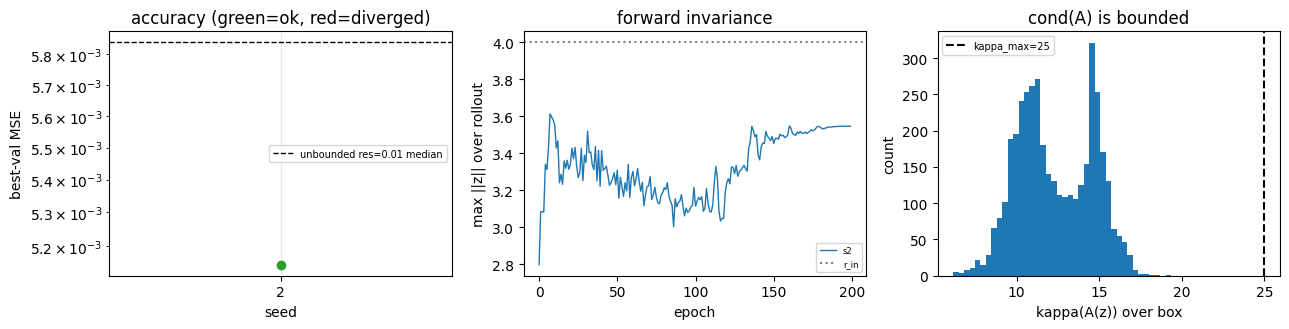

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
# (a) best-val per seed
ax[0].scatter(range(len(SEEDS)), bv, c=['tab:red' if d else 'tab:green' for d in div], zorder=3)
ax[0].axhline(5.84e-3, ls='--', c='k', lw=1, label='unbounded res=0.01 median')
ax[0].set_yscale('log'); ax[0].set_xticks(range(len(SEEDS))); ax[0].set_xticklabels(SEEDS)
ax[0].set_xlabel('seed'); ax[0].set_ylabel('best-val MSE'); ax[0].set_title('accuracy (green=ok, red=diverged)')
ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3)
# (b) latent norm over training (forward invariance)
for s, h in zip(SEEDS, hists):
    if h['zmax']: ax[1].plot(h['zmax'], lw=1, label=f's{s}')
ax[1].axhline(R_G*np.sqrt(M_LAT), ls=':', c='gray', label='r_in')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('max ||z|| over rollout'); ax[1].set_title('forward invariance'); ax[1].legend(fontsize=6)
# (c) kappa histogram over the box, all seeds
kaps = []
with torch.no_grad():
    for m in models:
        _, _, k = A_stats(m.dynamics.eval(), Zbox); kaps.append(k)
ax[2].hist(np.concatenate(kaps), bins=40); ax[2].axvline(KAPPA_MAX, ls='--', c='k', label=f'kappa_max={KAPPA_MAX:.0f}')
ax[2].set_xlabel('kappa(A(z)) over box'); ax[2].set_ylabel('count'); ax[2].set_title('cond(A) is bounded'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

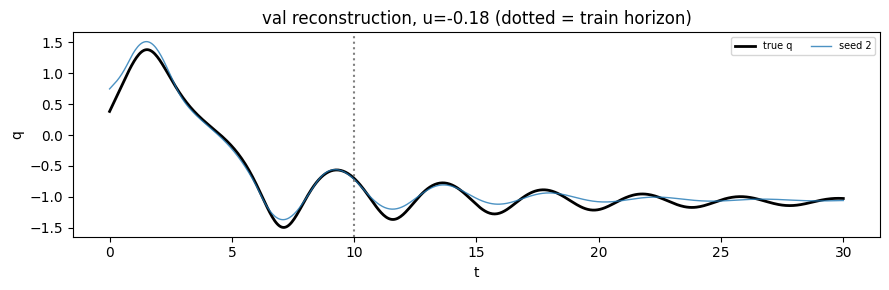

In [11]:
# reconstruction on one held-out trajectory, all 5 seeds overlaid
tt = np.arange(L_eval + 1) * h_dt; j = 0
plt.figure(figsize=(9, 3))
plt.plot(tt, Yva[j].numpy(), 'k-', lw=2, label='true q')
for s, m in zip(SEEDS, models):
    with torch.no_grad():
        yh, _ = rollout_y(m, Wva_d[j:j+1], Uva_d[j:j+1], L_eval, h_dt)
    plt.plot(tt, yh[0].cpu().numpy(), lw=1, alpha=0.8, label=f'seed {s}')
plt.axvline(L*h_dt, ls=':', c='gray'); plt.xlabel('t'); plt.ylabel('q'); plt.legend(fontsize=7, ncol=3)
plt.title(f'val reconstruction, u={Uva[j].item():.2f} (dotted = train horizon)'); plt.tight_layout(); plt.show()

## 7. How to read

- **Divergence** (headline): with the $\kappa$-bound, expect $0/5$ — in particular seed 2, which
  diverged under the unbounded $A$ at `res=0.01`, should now survive. The `max ||z||` panel should
  stay bounded (forward invariance held) rather than running away.
- **Accuracy**: best-val median should land near the unbounded reference ($\sim5\times10^{-3}$). A
  large regression would mean $\kappa_{\max}=25$ over-constrains the transient (raise it / raise
  `SKEW_FRAC`); no change or improvement means the cap is free.
- **$\kappa$ / certified radius**: box $\kappa$ must sit $\le\kappa_{\max}=25$ by construction, so the
  certified $R=\kappa\,r_{\mathrm{in}}$ drops from the unbounded $\sim\!100$–$400$ to $\le 25\,r_{\mathrm{in}}$.
- **Recovery**: $R^2\!\to\dot q$ should hold near the unbounded $0.65$ (the cap targets $A$, not $g$).

If seed 2 still diverges or accuracy drops, the next knobs are `KAPPA_MAX` (20→40 sweep) and
`SKEW_FRAC`; if it's clean, the follow-up is the orthogonal torchode swap.